## 1. Trajectory Automation

All the task classes in VLABench have the function `get_expert_skill_sequence`, the function provide the execuable object-centric operation sequences in the environment. Here we load task `play_texas_holdem` as an example, see the initial image rendered in environment.

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
dict_keys(['table', 'plate_seen', 'pear', 'orange', 'lemon', 'mango'])


""

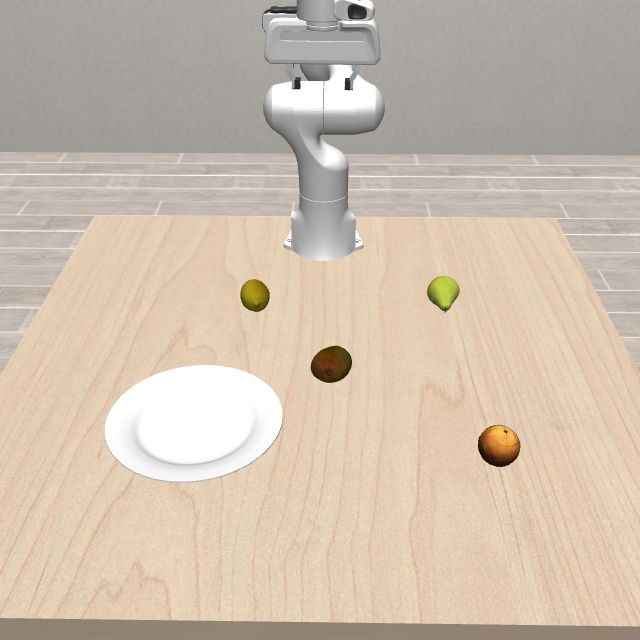

In [1]:
import numpy as np
import os
os.environ['DISPLAY']=':1'
from PIL import Image
import mediapy as media
from VLABench.robots import *
from VLABench.tasks import *
from VLABench.envs import load_env
os.environ["MUJOCO_GL"] = "egl"

task_name = "select_fruit"
env = load_env(task_name)
env.reset()
print(env.task.entities.keys())
media.show_image(env.render(camera_id=2, height=640, width=640))
# image = env.render(camera_id=2, height=640, width=640)
# Image.fromarray(image)

In [2]:
from functools import partial
from VLABench.utils.skill_lib import SkillLib


# env.task.entities.keys()
skill = partial(SkillLib.pick, target_entity_name = 'orange')
obs, waypoint, stage_success, task_success = skill(env)
key_frames = []
key_frames.extend([o['rgb'][2] for o in obs])

Checking if can connect to goal at 41 samples
Can connect to goal


In [ ]:
media.show_video(key_frames, fps=10)

In [ ]:
import moviepy as mpy
video = mpy.ImageSequenceClip(key_frames, fps=10)
video.write_videofile("output_video.mp4", codec="libx264")

You can see the expert skill sequence that should be carried out.

In [17]:
expert_skill_sequence = env.get_expert_skill_sequence()
expert_skill_sequence

[functools.partial(<function SkillLib.pick at 0x7fda9883e320>, target_entity_name='2_of_diamonds', prior_eulers=[[-3.141592653589793, 0, 0]]),
 functools.partial(<function SkillLib.lift at 0x7fda9883e830>, gripper_state=array([0., 0.]), lift_height=0.1),
 functools.partial(<function SkillLib.place at 0x7fda9883e3b0>, target_container_name='target_container'),
 functools.partial(<function SkillLib.pick at 0x7fda9883e320>, target_entity_name='2_of_clubs', prior_eulers=[[-3.141592653589793, 0, 0]]),
 functools.partial(<function SkillLib.lift at 0x7fda9883e830>, gripper_state=array([0., 0.]), lift_height=0.1),
 functools.partial(<function SkillLib.place at 0x7fda9883e3b0>, target_container_name='target_container')]

Carry out the skill sequence and the correspond observations and waypoints would be recorded.

In [ ]:
key_frames = []
for skill in expert_skill_sequence:
    obs, waypoint, stage_success, task_success = skill(env)
    key_frames.extend([o['rgb'][2] for o in obs])
    
media.show_video(key_frames, fps=10)

The above describes the main logic of trajectory generation. For detailed generation scripts, please refer to the `scripts/trajectory_generation.py`.